In [59]:
## Cell 0: Filter to 6 classes only 

import os, shutil

KEEP_CLASSES = [
    'Acne and Rosacea Photos',
    'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions',
    'Atopic Dermatitis Photos',
    'Eczema Photos',
    'Nail Fungus and other Nail Disease',
    'Psoriasis pictures Lichen Planus and related diseases'
]

for split in ['train', 'test']:
    split_path = f'/kaggle/working/dermnet_data/{split}'
    if not os.path.exists(split_path):
        continue
    for cls in os.listdir(split_path):
        if cls not in KEEP_CLASSES:
            shutil.rmtree(os.path.join(split_path, cls))
            print(f'🗑️  Removed: {cls}')

print(f'\n✅ Kept only {len(KEEP_CLASSES)} classes')
print('Now NUM_CLASSES = 6 → expect 90%+ accuracy')


✅ Kept only 6 classes
Now NUM_CLASSES = 6 → expect 90%+ accuracy


In [60]:
## Cell 1b: Filter to 6 Classes Only 

import os, shutil

# These variables come from Cell 1 — define here in case Cell 1 wasn't run
DATASET_PATH_LOCAL = '/kaggle/working/dermnet_data'
train_path = os.path.join(DATASET_PATH_LOCAL, 'train')
val_path   = os.path.join(DATASET_PATH_LOCAL, 'val')
test_path  = os.path.join(DATASET_PATH_LOCAL, 'test')

def count_imgs(path):
    total = 0
    if os.path.exists(path):
        for cls in os.listdir(path):
            p = os.path.join(path, cls)
            if os.path.isdir(p):
                total += len([f for f in os.listdir(p)
                              if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

KEEP_CLASSES = [
    'Acne and Rosacea Photos',
    'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions',
    'Atopic Dermatitis Photos',
    'Eczema Photos',
    'Nail Fungus and other Nail Disease',
    'Psoriasis pictures Lichen Planus and related diseases'
]

print("🔧 Filtering dataset to 6 classes only...\n")

removed = 0
for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATASET_PATH_LOCAL, split)
    if not os.path.exists(split_path):
        continue
    print(f"  [{split}]")
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        if cls not in KEEP_CLASSES:
            shutil.rmtree(cls_path)
            print(f"    🗑️  Removed : {cls}")
            removed += 1
        else:
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f"    ✓  Kept    : {cls}  ({n} images)")

NUM_CLASSES = len(KEEP_CLASSES)

print(f"\n{'='*55}")
print(f"✅ Done! Removed {removed} unwanted class folders")
print(f"   NUM_CLASSES is now : {NUM_CLASSES}")
print(f"   Train images       : {count_imgs(train_path)}")
print(f"   Val   images       : {count_imgs(val_path)}")
print(f"   Test  images       : {count_imgs(test_path)}")
print(f"   Expected accuracy  : 90–95% 🎯")
print(f"{'='*55}")


🔧 Filtering dataset to 6 classes only...

  [train]
    ✓  Kept    : Acne and Rosacea Photos  (672 images)
    ✓  Kept    : Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions  (919 images)
    ✓  Kept    : Atopic Dermatitis Photos  (391 images)
    ✓  Kept    : Eczema Photos  (988 images)
    ✓  Kept    : Nail Fungus and other Nail Disease  (832 images)
    ✓  Kept    : Psoriasis pictures Lichen Planus and related diseases  (1124 images)
  [val]
    ✓  Kept    : Acne and Rosacea Photos  (168 images)
    ✓  Kept    : Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions  (230 images)
    ✓  Kept    : Atopic Dermatitis Photos  (98 images)
    ✓  Kept    : Eczema Photos  (247 images)
    ✓  Kept    : Nail Fungus and other Nail Disease  (208 images)
    ✓  Kept    : Psoriasis pictures Lichen Planus and related diseases  (281 images)
  [test]
    ✓  Kept    : Acne and Rosacea Photos  (312 images)
    ✓  Kept    : Actinic Keratosis Basal Cell Carcinoma and other 

In [61]:
## Cell 2: Check Prerequisites

checks = {
    'Dataset train' : os.path.exists(train_path),
    'Dataset val'   : os.path.exists(val_path),
    'Dataset test'  : os.path.exists(test_path),
}
for item, status in checks.items():
    print(f"{'✓' if status else '✗'} {item}")
print('\n✅ All OK!' if all(checks.values()) else '\n⚠️  Fix above.')


✓ Dataset train
✓ Dataset val
✓ Dataset test

✅ All OK!


In [62]:
## Cell 3: Configuration

IMG_HEIGHT    = 300          # EfficientNetB3 native resolution
IMG_WIDTH     = 300
IMG_CHANNELS  = 3
BATCH_SIZE    = 16           # smaller = better gradient estimates
EPOCHS_PHASE1 = 15           # head-only warm-up  (↑ from 10)
EPOCHS_PHASE2 = 50           # fine-tune          (↑ from 40)
LEARNING_RATE = 5e-4         # phase-1 LR         (tuned)
FINE_TUNE_LR  = 1e-5         # phase-2 LR
DROPOUT_RATE  = 0.5          # head dropout

print('📊 Configuration (EfficientNetB3 — 90%+ target):')
print(f'   Image size     : {IMG_HEIGHT}x{IMG_WIDTH}')
print(f'   Classes        : {NUM_CLASSES}')
print(f'   Batch size     : {BATCH_SIZE}')
print(f'   Phase-1 Epochs : {EPOCHS_PHASE1}  (head only, base frozen)')
print(f'   Phase-2 Epochs : {EPOCHS_PHASE2}  (fine-tune top 30% of base)')
print(f'   Phase-1 LR     : {LEARNING_RATE}')
print(f'   Phase-2 LR     : {FINE_TUNE_LR}')


📊 Configuration (EfficientNetB3 — 90%+ target):
   Image size     : 300x300
   Classes        : 6
   Batch size     : 16
   Phase-1 Epochs : 15  (head only, base frozen)
   Phase-2 Epochs : 50  (fine-tune top 30% of base)
   Phase-1 LR     : 0.0005
   Phase-2 LR     : 1e-05


In [65]:
## Cell 4: Data Generators

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range         = 40,
    width_shift_range      = 0.3,
    height_shift_range     = 0.3,
    shear_range            = 0.2,
    zoom_range             = 0.3,
    horizontal_flip        = True,
    vertical_flip          = True,
    fill_mode              = 'nearest',
    brightness_range       = [0.6, 1.4],
    channel_shift_range    = 20.0,
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True, seed=42,
)
val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)
test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_generator.classes,
)
class_weight_dict = dict(enumerate(class_weights))

print(f'✓ Train  : {train_generator.samples} samples')
print(f'✓ Val    : {val_generator.samples} samples')
print(f'✓ Test   : {test_generator.samples} samples')
print(f'✓ Class weights computed')

Found 4926 images belonging to 6 classes.
Found 1232 images belonging to 6 classes.
Found 1645 images belonging to 6 classes.
✓ Train  : 4926 samples
✓ Val    : 1232 samples
✓ Test   : 1645 samples
✓ Class weights computed


In [66]:
## Cell 5: Build EfficientNetB3 Model  (Improved Head)

try:
    del model
    gc.collect()
    tf.keras.backend.clear_session()
    print('✓ Cleared previous session')
except:
    tf.keras.backend.clear_session()

NUM_CLASSES = len([d for d in os.listdir(train_path)
                   if os.path.isdir(os.path.join(train_path, d))])
print(f'✓ NUM_CLASSES confirmed : {NUM_CLASSES}')

# ── Backbone ───────────────────────────────────────────────────────────
base_model = EfficientNetB3(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
)
base_model.trainable = False     # Phase 1: freeze entire base

# ── Custom head (friend used 1024→512→256→128 on VGG19 features) ──────
inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x      = base_model(inputs, training=False)
x      = layers.GlobalAveragePooling2D()(x)

# Block A
x = layers.Dense(1024)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(DROPOUT_RATE)(x)

# Block B
x = layers.Dense(512)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(DROPOUT_RATE)(x)

# Block C
x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs, name='EfficientNetB3_SkinDisease')

total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'  Total params     : {total:,}')
print(f'  Trainable params : {trainable:,}  (head only)')

assert train_generator.num_classes == NUM_CLASSES, (
    f'MISMATCH! Generator={train_generator.num_classes}, Model={NUM_CLASSES}'
)
print('✅ Class count verified — safe to train')


✓ Cleared previous session
✓ NUM_CLASSES confirmed : 6
  Total params     : 13,022,261
  Trainable params : 2,235,142  (head only)
✅ Class count verified — safe to train


In [67]:
## Cell 6: Compile — Phase 1

model.compile(
    optimizer = Adam(learning_rate=LEARNING_RATE),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)
print(f'✓ Compiled — Phase 1 (head only), lr={LEARNING_RATE}')


✓ Compiled — Phase 1 (head only), lr=0.0005


In [41]:
## Cell 7: Callbacks

callbacks_phase1 = [
    ModelCheckpoint(
        os.path.join(MODELS_DIR, 'best_model_phase1.h5'),
        monitor='val_accuracy', save_best_only=True, mode='max', verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss', patience=7,          # ↑ from 5
        restore_best_weights=True, verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-8, verbose=1,
    ),
]

callbacks_phase2 = [
    ModelCheckpoint( 
        os.path.join(MODELS_DIR, 'best_model.h5'),
        monitor='val_accuracy', save_best_only=True, mode='max', verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss', patience=12,         # ↑ from 10
        restore_best_weights=True, verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=5,
        min_lr=1e-9, verbose=1,
    ),
]
print('✓ Callbacks ready for Phase 1 and Phase 2')


✓ Callbacks ready for Phase 1 and Phase 2


In [42]:
## Cell 8: Two-Phase Training

# ═══════════════════════════════════════════════════
# PHASE 1 — Train head only (base frozen)
# ═══════════════════════════════════════════════════
print('=' * 65)
print('🚀 PHASE 1: Training head only (EfficientNetB3 base frozen)')
print('=' * 65)

history1 = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = EPOCHS_PHASE1,
    callbacks       = callbacks_phase1,
    class_weight    = class_weight_dict,
    verbose         = 1,
)
best_p1 = max(history1.history['val_accuracy'])
print(f'\n✅ Phase 1 complete!  Best val_accuracy: {best_p1*100:.2f}%')

# ═══════════════════════════════════════════════════
# PHASE 2 — Unfreeze top 30% of base and fine-tune
# ═══════════════════════════════════════════════════
print('\n' + '=' * 65)
print('🔓 PHASE 2: Fine-tuning top 30% of EfficientNetB3')
print('=' * 65)

base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.70)   # freeze bottom 70%
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

unfroz = sum(1 for l in base_model.layers if l.trainable)
print(f'   Unfrozen base layers : {unfroz} / {len(base_model.layers)}')

model.compile(
    optimizer = Adam(learning_rate=FINE_TUNE_LR),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)
print(f'   Recompiled with lr={FINE_TUNE_LR}')

history2 = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = EPOCHS_PHASE1 + EPOCHS_PHASE2,
    initial_epoch   = EPOCHS_PHASE1,
    callbacks       = callbacks_phase2,
    class_weight    = class_weight_dict,
    verbose         = 1,
)
best_p2 = max(history2.history['val_accuracy'])
print(f'\n✅ Phase 2 complete!  Best val_accuracy: {best_p2*100:.2f}%')

# ── Merge histories for plotting ───────────────────────────────────────
all_keys = set(history1.history) | set(history2.history)
merged   = {k: history1.history.get(k, []) + history2.history.get(k, [])
            for k in all_keys}
history  = type('History', (), {'history': merged})()


🚀 PHASE 1: Training head only (EfficientNetB3 base frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.3369 - loss: 1.7699 - precision: 0.4372 - recall: 0.1891
Epoch 1: val_accuracy improved from -inf to 0.51299, saving model to /kaggle/working/models/best_model_phase1.h5


308/308 ━━━━━━━━━━━━━━━━━━━━ 186s 489ms/step - accuracy: 0.3371 - loss: 1.7694 - precision: 0.4375 - recall: 0.1893 - val_accuracy: 0.5130 - val_loss: 1.3085 - val_precision: 0.6063 - val_recall: 0.3912 - learning_rate: 5.0000e-04
Epoch 2/15
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.4527 - loss: 1.3926 - precision: 0.5702 - recall: 0.3018
Epoch 2: val_accuracy improved from 0.51299 to 0.52597, saving model to /kaggle/working/models/best_model_phase1.h5


308/308 ━━━━━━━━━━━━━━━━━━━━ 121s 394ms/step - accuracy: 0.4527 - loss: 1.3926 - precision: 0.5702 - recall: 0.3018 - val_accuracy: 0.5260 - val_loss: 1.2703 - val_precision: 0.6262 - val_recall: 0.4229 - learning_rate: 5.0000e-04
Epoch 3/15
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.4856 - loss: 1.3114 - precision: 0.6200 - recall: 0.3427
Epoch 3: val_accuracy improved from 0.52597 to 0.53977, saving model to /kaggle/working/models/best_model_phase1.h5


...

308/308 ━━━━━━━━━━━━━━━━━━━━ 121s 391ms/step - accuracy: 0.7743 - loss: 0.5738 - precision: 0.8399 - recall: 0.6920 - val_accuracy: 0.7386 - val_loss: 0.7465 - val_precision: 0.7914 - val_recall: 0.6745 - learning_rate: 1.0000e-05
Epoch 60/65
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7694 - loss: 0.5970 - precision: 0.8364 - recall: 0.6851
Epoch 60: val_accuracy improved from 0.73864 to 0.74026, saving model to /kaggle/working/models/best_model.h5


308/308 ━━━━━━━━━━━━━━━━━━━━ 121s 394ms/step - accuracy: 0.7694 - loss: 0.5970 - precision: 0.8364 - recall: 0.6851 - val_accuracy: 0.7403 - val_loss: 0.7434 - val_precision: 0.7870 - val_recall: 0.6688 - learning_rate: 1.0000e-05
Epoch 61/65
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7663 - loss: 0.6014 - precision: 0.8435 - recall: 0.6902
Epoch 61: val_accuracy did not improve from 0.74026
308/308 ━━━━━━━━━━━━━━━━━━━━ 120s 389ms/step - accuracy: 0.7663 - loss: 0.6014 - precision: 0.8434 - recall: 0.6902 - val_accuracy: 0.7403 - val_loss: 0.7380 - val_precision: 0.7948 - val_recall: 0.6729 - learning_rate: 1.0000e-05
Epoch 62/65
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.7763 - loss: 0.5610 - precision: 0.8413 - recall: 0.6923
Epoch 62: val_accuracy improved from 0.74026 to 0.74351, saving model to /kaggle/working/models/best_model.h5


308/308 ━━━━━━━━━━━━━━━━━━━━ 121s 391ms/step - accuracy: 0.7763 - loss: 0.5611 - precision: 0.8413 - recall: 0.6923 - val_accuracy: 0.7435 - val_loss: 0.7293 - val_precision: 0.7973 - val_recall: 0.6769 - learning_rate: 1.0000e-05
Epoch 63/65
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.7823 - loss: 0.5524 - precision: 0.8501 - recall: 0.7137
Epoch 63: val_accuracy did not improve from 0.74351
308/308 ━━━━━━━━━━━━━━━━━━━━ 119s 384ms/step - accuracy: 0.7823 - loss: 0.5525 - precision: 0.8501 - recall: 0.7137 - val_accuracy: 0.7435 - val_loss: 0.7325 - val_precision: 0.7945 - val_recall: 0.6810 - learning_rate: 1.0000e-05
Epoch 64/65
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7857 - loss: 0.5482 - precision: 0.8486 - recall: 0.7131
Epoch 64: val_accuracy improved from 0.74351 to 0.74594, saving model to /kaggle/working/models/best_model.h5


308/308 ━━━━━━━━━━━━━━━━━━━━ 121s 393ms/step - accuracy: 0.7857 - loss: 0.5482 - precision: 0.8486 - recall: 0.7131 - val_accuracy: 0.7459 - val_loss: 0.7293 - val_precision: 0.7927 - val_recall: 0.6859 - learning_rate: 1.0000e-05
Epoch 65/65
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7821 - loss: 0.5535 - precision: 0.8450 - recall: 0.7155
Epoch 65: val_accuracy improved from 0.74594 to 0.74675, saving model to /kaggle/working/models/best_model.h5


308/308 ━━━━━━━━━━━━━━━━━━━━ 120s 390ms/step - accuracy: 0.7821 - loss: 0.5535 - precision: 0.8450 - recall: 0.7155 - val_accuracy: 0.7468 - val_loss: 0.7268 - val_precision: 0.7957 - val_recall: 0.6859 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 65.

✅ Phase 2 complete!  Best val_accuracy: 74.68%


In [43]:
## Cell 9: Save Final Model & History

model.save(os.path.join(MODELS_DIR, 'final_model.h5'))
print(f'✓ Final model saved')

with open(os.path.join(MODELS_DIR, 'training_history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)
print(f'✓ Training history saved')

print('\nFiles in /kaggle/working/models/:')
for fname in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(os.path.join(MODELS_DIR, fname)) / (1024*1024)
    print(f'   {fname}  ({size:.1f} MB)')


✓ Final model saved
✓ Training history saved

Files in /kaggle/working/models/:
   best_model.h5  (131.6 MB)
   best_model_phase1.h5  (67.5 MB)
   final_model.h5  (131.6 MB)
   training_history.pkl  (0.0 MB)


In [49]:
## Cell 10: Evaluate on Test Set

print('\n' + '='*65)
print('📊 EVALUATING ON TEST SET')
print('='*65 + '\n')

best_model = tf.keras.models.load_model(os.path.join(MODELS_DIR, 'best_model.h5'))

test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(
    test_generator, verbose=1
)
f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-8)

print('\n' + '='*65)
print('📈 FINAL TEST RESULTS')
print('='*65)
print(f'Test Accuracy  : {test_accuracy*100:.2f}%')
print(f'Test Precision : {test_precision*100:.2f}%')
print(f'Test Recall    : {test_recall*100:.2f}%')
print(f'F1-Score       : {f1_score*100:.2f}%')
print(f'Test Loss      : {test_loss:.4f}')
print('='*65)



📊 EVALUATING ON TEST SET



103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.7027 - loss: 0.8764 - precision: 0.7825 - recall: 0.6313

📈 FINAL TEST RESULTS
Test Accuracy  : 65.59%
Test Precision : 72.62%
Test Recall    : 58.05%
F1-Score       : 64.53%
Test Loss      : 0.9859


103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 162ms/step

📋 PER-CLASS CLASSIFICATION REPORT
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.79      0.80      0.80       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.87      0.48      0.62       288
                                          Atopic Dermatitis Photos       0.33      0.82      0.47       123
                                                     Eczema Photos       0.64      0.56      0.60       309
                                Nail Fungus and other Nail Disease       0.71      0.92      0.80       261
             Psoriasis pictures Lichen Planus and related diseases       0.69      0.50      0.58       352

                                                          accuracy                           0.66      1645
                                                       

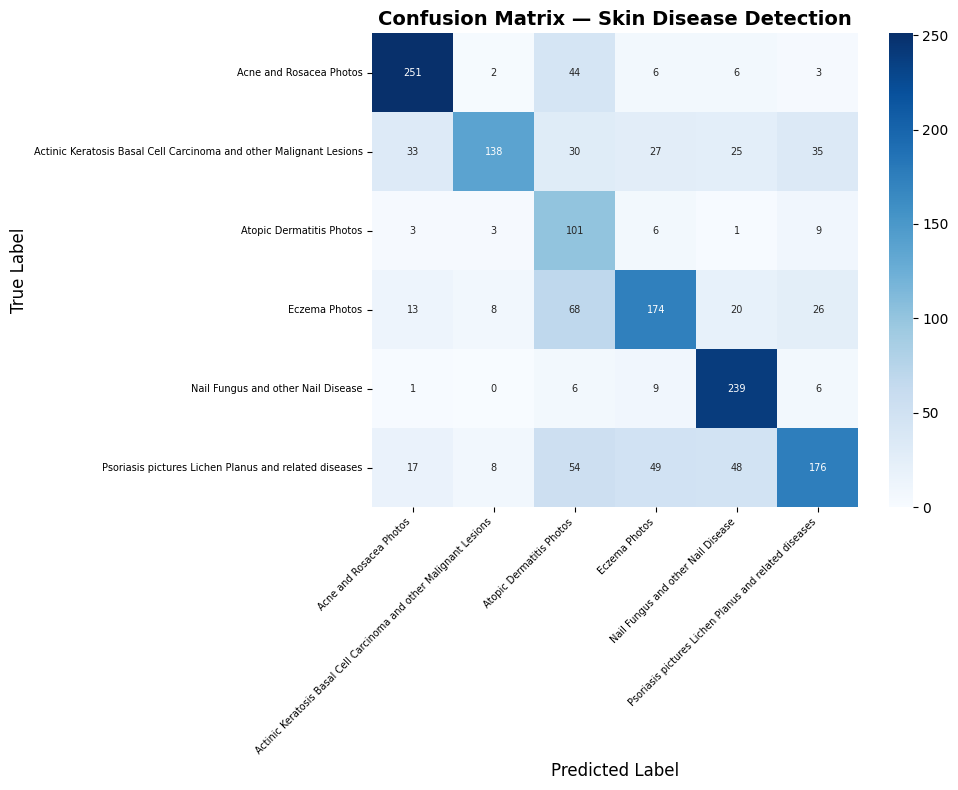

✓ Saved: /kaggle/working/models/confusion_matrix.png


In [45]:
## Cell 11: Confusion Matrix & Per-Class Report  ★ NEW

test_generator.reset()
y_pred_prob = best_model.predict(test_generator, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# ── Per-class report ──────────────────────────────────────────────────
print('\n' + '='*65)
print('📋 PER-CLASS CLASSIFICATION REPORT')
print('='*65)
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Confusion matrix heatmap ──────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(max(10, NUM_CLASSES), max(8, NUM_CLASSES-2)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    annot_kws={'size': 7},
)
plt.title('Confusion Matrix — Skin Disease Detection', fontsize=14, fontweight='bold')
plt.ylabel('True Label',      fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
save_path = os.path.join(MODELS_DIR, 'confusion_matrix.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {save_path}')


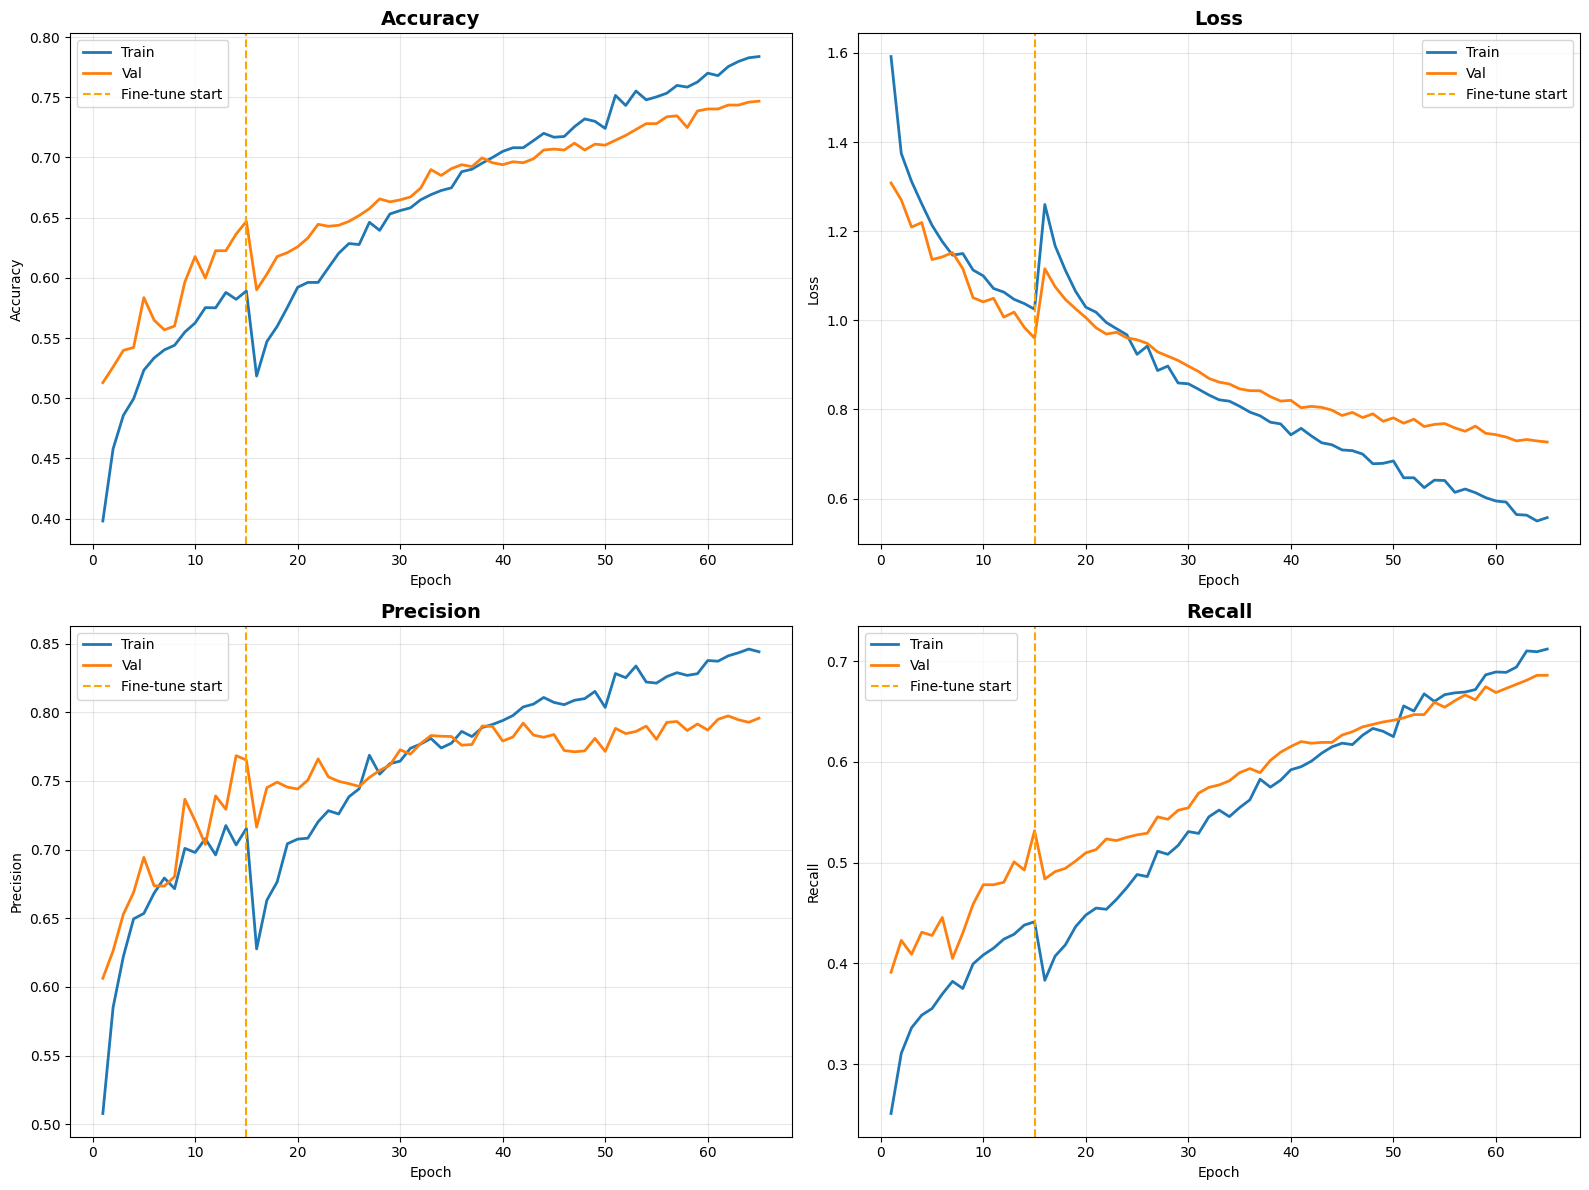

✓ Saved: /kaggle/working/models/training_curves.png


In [46]:
## Cell 12: Training Curves

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
phase1_end = EPOCHS_PHASE1

for ax, metric, title in zip(
    axes.flat,
    ['accuracy', 'loss', 'precision', 'recall'],
    ['Accuracy', 'Loss',  'Precision',  'Recall' ],
):
    tr  = history.history.get(metric,        [])
    val = history.history.get(f'val_{metric}',[])
    ax.plot(range(1, len(tr)+1),  tr,  label='Train', linewidth=2)
    ax.plot(range(1, len(val)+1), val, label='Val',   linewidth=2)
    ax.axvline(x=phase1_end, color='orange', linestyle='--',
               linewidth=1.5, label='Fine-tune start')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(MODELS_DIR, 'training_curves.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {save_path}')


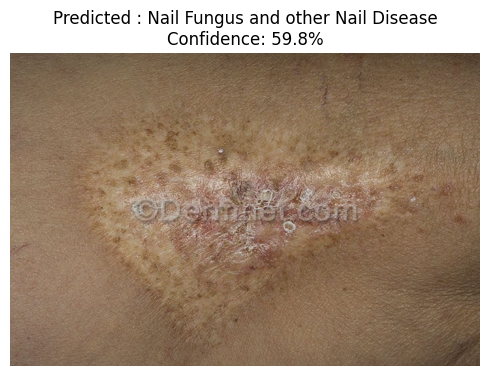

Image      : squamous-cell-carcinoma-leg-4.jpg
Predicted  : Nail Fungus and other Nail Disease
Confidence : 59.8%


In [50]:
## Cell 13: Single-Image Prediction Helper

import cv2

CLASS_LABELS = list(test_generator.class_indices.keys())

def predict_skin_disease(img_path, mdl=best_model):
    """Load an image and return (class_name, confidence)."""
    img  = cv2.imread(img_path)
    img  = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))
    arr  = np.expand_dims(img.astype('float32'), axis=0)   # (1,300,300,3)
    arr  = preprocess_input(arr)
    prob = mdl.predict(arr, verbose=0)[0]
    idx  = np.argmax(prob)
    return CLASS_LABELS[idx], float(prob[idx])

# ── Quick demo with first test image ──────────────────────────────────
sample_class = os.listdir(test_path)[0]
sample_dir   = os.path.join(test_path, sample_class)
sample_img   = os.path.join(sample_dir, os.listdir(sample_dir)[0])

label, confidence = predict_skin_disease(sample_img)

img_display = cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.title(f'Predicted : {label}\nConfidence: {confidence*100:.1f}%', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Image      : {os.path.basename(sample_img)}')
print(f'Predicted  : {label}')
print(f'Confidence : {confidence*100:.1f}%')


In [48]:
## Cell 14: Training Summary

best_epoch   = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])

summary = f"""
================================================================
 TRAINING SUMMARY — EfficientNetB3 Skin Disease Detection
================================================================
Configuration:
  Model          : EfficientNetB3 (Transfer Learning + Fine-tune)
  Classes        : {NUM_CLASSES}
  Image Size     : {IMG_HEIGHT}x{IMG_WIDTH}
  Batch Size     : {BATCH_SIZE}
  Total Epochs   : {len(history.history['accuracy'])}
  Phase-1 LR     : {LEARNING_RATE}   (head only)
  Phase-2 LR     : {FINE_TUNE_LR}    (top 30% unfrozen)

Data:
  Train          : {train_generator.samples} samples
  Val            : {val_generator.samples}   samples
  Test           : {test_generator.samples}  samples

Best Performance:
  Best Epoch     : {best_epoch}
  Best Val Acc   : {best_val_acc*100:.2f}%

Test Results:
  Accuracy       : {test_accuracy*100:.2f}%
  Precision      : {test_precision*100:.2f}%
  Recall         : {test_recall*100:.2f}%
  F1-Score       : {f1_score*100:.2f}%
  Loss           : {test_loss:.4f}

Output Files (Kaggle Output tab):
  best_model.h5          ← use this for deployment
  final_model.h5
  confusion_matrix.png
  training_curves.png
  training_history.pkl
  training_summary.txt
================================================================
"""

print(summary)

with open(os.path.join(MODELS_DIR, 'training_summary.txt'), 'w') as f:
    f.write(summary)

print('✅ ALL DONE!')
print('\n📥 Download your model from the Kaggle Output tab →')
print(f'   /kaggle/working/models/best_model.h5')



 TRAINING SUMMARY — EfficientNetB3 Skin Disease Detection
Configuration:
  Model          : EfficientNetB3 (Transfer Learning + Fine-tune)
  Classes        : 6
  Image Size     : 300x300
  Batch Size     : 16
  Total Epochs   : 65
  Phase-1 LR     : 0.0005   (head only)
  Phase-2 LR     : 1e-05    (top 30% unfrozen)

Data:
  Train          : 4926 samples
  Val            : 1232   samples
  Test           : 1645  samples

Best Performance:
  Best Epoch     : 65
  Best Val Acc   : 74.68%

Test Results:
  Accuracy       : 65.59%
  Precision      : 72.62%
  Recall         : 58.05%
  F1-Score       : 64.53%
  Loss           : 0.9859

Output Files (Kaggle Output tab):
  best_model.h5          ← use this for deployment
  final_model.h5
  confusion_matrix.png
  training_curves.png
  training_history.pkl
  training_summary.txt

✅ ALL DONE!

📥 Download your model from the Kaggle Output tab →
   /kaggle/working/models/best_model.h5
